In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd


import umap
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import pairwise_distances_argmin_min

In [2]:
from Clustering import run_kmeans, elbow_and_silhouette, visualize_umap, visualize_pca, silhouette_plot, read_newdata, read_outliers


In [3]:
info_clustering = read_newdata()

In [4]:
info_clustering.set_index('customer_id', inplace=True)

In [5]:
excluded_cols = ['customer_gender', 'latitude', 'longitude', 'has_loyalty_card']

In [6]:
info_clustering_kmeans = info_clustering.copy()

K=2: Inertia=280239, Silhouette=0.1658
K=3: Inertia=258108, Silhouette=0.1402
K=4: Inertia=230464, Silhouette=0.1617
K=5: Inertia=214670, Silhouette=0.1690
K=6: Inertia=199794, Silhouette=0.1806
K=7: Inertia=194744, Silhouette=0.1728
K=8: Inertia=183450, Silhouette=0.1724
K=9: Inertia=177743, Silhouette=0.1738
K=10: Inertia=174474, Silhouette=0.1715


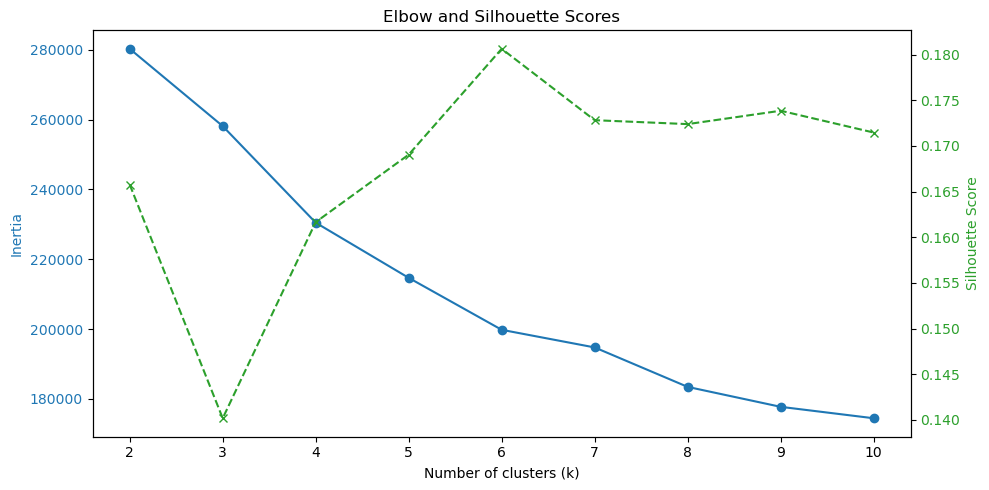

In [7]:
inertias, silhouettes = elbow_and_silhouette(info_clustering_kmeans, exclude_cols=excluded_cols, max_k=10)

In [8]:
labels, centroids, score = run_kmeans(info_clustering_kmeans, exclude_cols=excluded_cols, k=6)
print(f"Final Silhouette Score: {score:.4f}")

Final Silhouette Score: 0.1806


In [9]:
info_clustering_kmeans['kmeans_cluster'] = labels


In [10]:
info_clustering_kmeans

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,...,longitude,age,hour_sin,hour_cos,years_education,years_since_first_transaction,lifetime_spend_techonology,has_loyalty_card,customer_gender,kmeans_cluster
customer_id,,,,,,,,,,,,,,,,,,,,,
29930,1.0,1.0,0.0,0.5,-0.375254,0.323394,1.214118,0.567444,1.029630,1.222782,...,0.895939,-0.027101,-0.183013,-0.366025,-0.6,-0.428571,0.632947,0,1,3
6813,-1.0,0.0,-1.0,0.5,-0.332876,0.399083,-0.809412,-0.622151,-0.240000,-0.337702,...,-0.187761,0.855364,-0.353553,-0.224745,0.0,0.285714,-0.656762,1,0,2
39451,1.0,1.0,-1.0,1.5,0.008118,1.308486,1.256471,1.274336,0.622222,1.300403,...,0.281558,-0.600101,-0.353553,-0.224745,-0.6,0.571429,0.326415,0,1,3
16415,0.0,0.0,0.0,1.0,1.658394,-0.213303,0.658824,-0.146956,0.118519,0.817540,...,0.220402,0.150113,-0.353553,-0.224745,1.4,0.428571,0.042167,1,0,5
22853,0.0,0.0,0.0,0.0,0.551196,1.857798,-0.157647,-0.131939,-1.334815,-0.638105,...,-0.533152,0.674102,-0.707107,1.000000,1.4,0.285714,0.103343,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37071,0.0,0.0,-1.0,-0.5,2.299522,0.423165,0.192941,0.901046,-0.320000,1.014113,...,1.515551,-0.895312,-0.612372,0.292893,-0.6,-0.428571,0.549050,0,1,1
27422,0.0,0.0,-1.0,0.0,0.031613,0.066514,0.710588,0.010727,0.440000,-0.113911,...,-0.348471,-0.430278,-0.183013,-0.366025,-0.6,-0.571429,0.206030,1,0,5
39540,0.0,-1.0,0.0,-0.5,-0.039657,-0.048165,-0.432941,-0.214535,-0.583704,0.797379,...,-0.439728,-0.948547,-0.683013,0.633975,-0.6,-0.428571,1.414027,0,1,4


In [11]:
print(info_clustering_kmeans['kmeans_cluster'].value_counts().sort_index())

kmeans_cluster
0    4558
1    4123
2    8817
3    4702
4    4599
5    5629
Name: count, dtype: int64


In [12]:
feature_cols = info_clustering_kmeans.drop(columns=excluded_cols).columns

centroids_df_kmeans = (
    pd.DataFrame(centroids, columns=feature_cols[:-1])
      .assign(kmeans_cluster = range(6))   
      .set_index("kmeans_cluster")         
)

display(centroids_df_kmeans.head(20))


,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,age,hour_sin,hour_cos,years_education,years_since_first_transaction,lifetime_spend_techonology
kmeans_cluster,,,,,,,,,,,,,,,,,,,,
0,-0.009258,-0.691795,-0.286749,0.056670,-0.238741,1.736377,-0.117001,-0.299107,-1.250091,-0.575105,0.114243,-0.331777,-0.212748,-0.342587,0.062382,-0.130574,0.374654,0.185827,0.054190,-0.203821
1,-0.490565,-0.017948,-0.898278,-0.463691,1.817884,0.695609,0.135531,0.836035,0.725008,0.953117,0.327949,0.433694,0.223749,-0.301476,0.077689,-0.084256,0.432650,0.367160,0.175323,0.540466
2,-0.070536,-0.044009,0.096474,0.138488,-0.243995,-0.067712,-0.623907,-0.386978,-0.272341,-0.293485,-0.334088,-0.115883,-0.352333,0.913462,-0.153010,-0.005151,0.324214,-0.311688,-0.137513,-0.502449
3,1.451170,0.853892,-0.171842,0.017886,0.207292,0.406278,0.805821,0.852009,0.892565,0.598001,0.386394,0.177991,1.111434,-0.100775,0.101581,0.290258,-0.086059,0.093024,0.314486,0.495682
4,-0.722484,-0.753769,-0.234902,-0.752636,0.289627,-0.198699,0.060939,0.327594,-0.077665,0.174955,-0.414817,-0.113407,0.057636,0.172960,-0.045196,-0.187144,0.856844,0.129891,-0.383940,1.386263
5,-0.057650,0.005644,0.005538,0.414483,0.725046,-0.114148,0.575500,0.059031,0.176894,0.275534,0.868236,0.179222,0.796658,0.379881,0.085629,-0.021146,0.343856,0.097941,0.425960,0.088941


In [13]:
X = info_clustering_kmeans.drop(columns=['kmeans_cluster'] + excluded_cols)

/Users/davidcarrilho/anaconda3/envs/MachineLeaning2/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


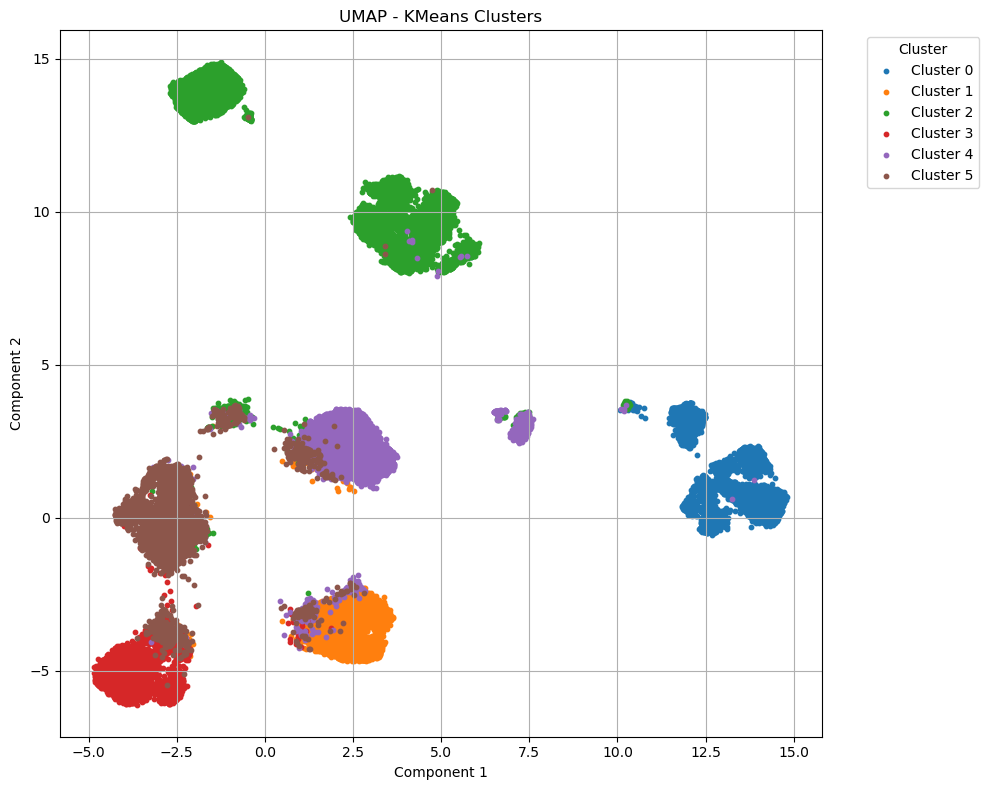

In [14]:
umap_object = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_embedding = umap_object.fit_transform(X)

clusters = info_clustering_kmeans.loc[X.index, 'kmeans_cluster']
visualize_umap(umap_embedding, labels=info_clustering_kmeans['kmeans_cluster'], title='UMAP - KMeans Clusters')

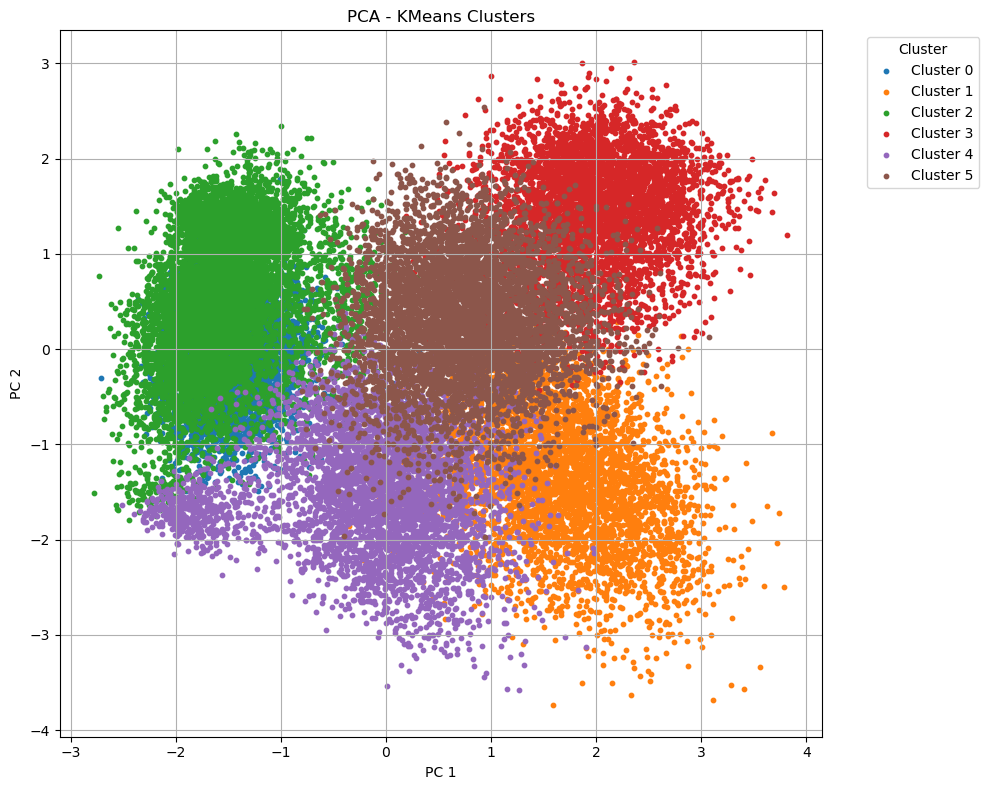

In [15]:
excluded = ['kmeans_cluster', 'customer_gender', 'latitude', 'longitude', 'has_loyalty_card']
X = info_clustering_kmeans.drop(columns=excluded)

clusters = info_clustering_kmeans.loc[X.index, 'kmeans_cluster']

pca = PCA(n_components=2)
pca_embedding = pca.fit_transform(X)

visualize_pca(pca_embedding, labels=info_clustering_kmeans['kmeans_cluster'], title='PCA - KMeans Clusters')

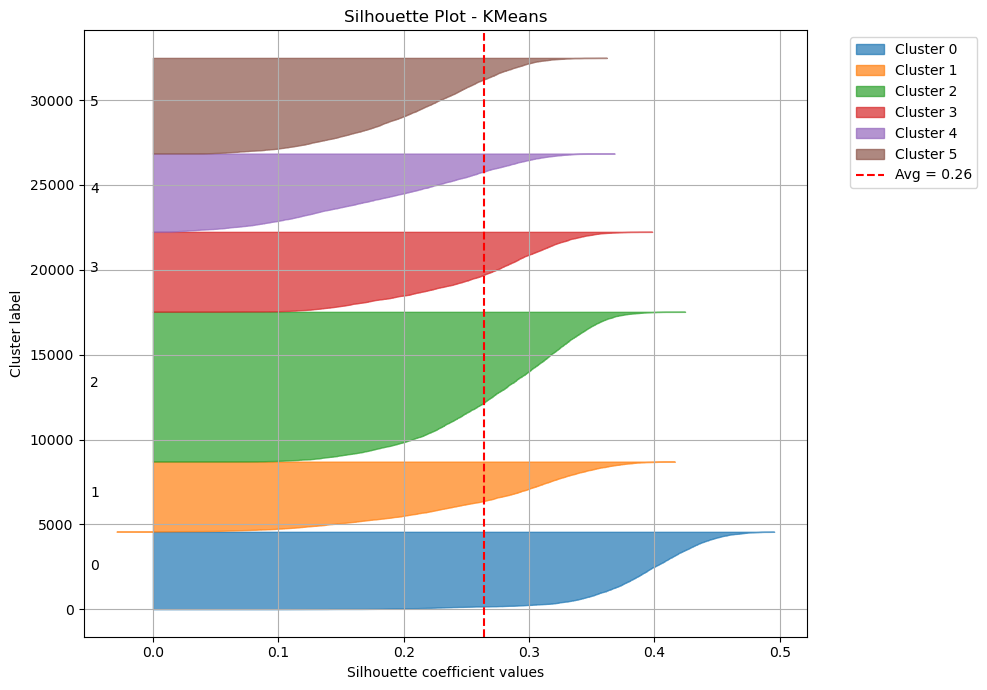

In [16]:
X = info_clustering_kmeans.drop(columns=excluded_cols)

cluster_labels = info_clustering_kmeans['kmeans_cluster']

silhouette_plot(X, info_clustering_kmeans['kmeans_cluster'].values, title='Silhouette Plot - KMeans')


## Hierarchical + KMeans Centroids


In [17]:
info_clustering_hierarchical = info_clustering.copy()

In [18]:
labels20, centroids20, sil20 = run_kmeans(
    info_clustering_hierarchical,                
    k=20,
    exclude_cols=excluded_cols,
    random_state=42,
)
print(f"Silhouette (k=20) = {sil20:.3f}")

Silhouette (k=20) = 0.119


In [19]:
info_clustering_hierarchical["kmeans20_cluster"] = labels20

In [20]:
info_clustering_hierarchical

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,...,longitude,age,hour_sin,hour_cos,years_education,years_since_first_transaction,lifetime_spend_techonology,has_loyalty_card,customer_gender,kmeans20_cluster
customer_id,,,,,,,,,,,,,,,,,,,,,
29930,1.0,1.0,0.0,0.5,-0.375254,0.323394,1.214118,0.567444,1.029630,1.222782,...,0.895939,-0.027101,-0.183013,-0.366025,-0.6,-0.428571,0.632947,0,1,13
6813,-1.0,0.0,-1.0,0.5,-0.332876,0.399083,-0.809412,-0.622151,-0.240000,-0.337702,...,-0.187761,0.855364,-0.353553,-0.224745,0.0,0.285714,-0.656762,1,0,8
39451,1.0,1.0,-1.0,1.5,0.008118,1.308486,1.256471,1.274336,0.622222,1.300403,...,0.281558,-0.600101,-0.353553,-0.224745,-0.6,0.571429,0.326415,0,1,13
16415,0.0,0.0,0.0,1.0,1.658394,-0.213303,0.658824,-0.146956,0.118519,0.817540,...,0.220402,0.150113,-0.353553,-0.224745,1.4,0.428571,0.042167,1,0,1
22853,0.0,0.0,0.0,0.0,0.551196,1.857798,-0.157647,-0.131939,-1.334815,-0.638105,...,-0.533152,0.674102,-0.707107,1.000000,1.4,0.285714,0.103343,1,1,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37071,0.0,0.0,-1.0,-0.5,2.299522,0.423165,0.192941,0.901046,-0.320000,1.014113,...,1.515551,-0.895312,-0.612372,0.292893,-0.6,-0.428571,0.549050,0,1,6
27422,0.0,0.0,-1.0,0.0,0.031613,0.066514,0.710588,0.010727,0.440000,-0.113911,...,-0.348471,-0.430278,-0.183013,-0.366025,-0.6,-0.571429,0.206030,1,0,19
39540,0.0,-1.0,0.0,-0.5,-0.039657,-0.048165,-0.432941,-0.214535,-0.583704,0.797379,...,-0.439728,-0.948547,-0.683013,0.633975,-0.6,-0.428571,1.414027,0,1,18


In [21]:
feature_cols = (
    info_clustering_hierarchical
      .columns
      .difference(excluded_cols + ['kmeans20_cluster', 'macro_cluster'])  
)

In [22]:
centroids_df_hierarchical = pd.DataFrame(centroids20,
                           columns=feature_cols)
centroids_df_hierarchical.index = [f'C{i}' for i in range(20)]

In [23]:
centroids_df_hierarchical

,age,distinct_stores_visited,hour_cos,hour_sin,kids_home,lifetime_spend_alcohol_drinks,lifetime_spend_fish,lifetime_spend_groceries,lifetime_spend_hygiene,lifetime_spend_meat,lifetime_spend_nonalcohol_drinks,lifetime_spend_petfood,lifetime_spend_techonology,lifetime_spend_vegetables,lifetime_total_distinct_products,number_complaints,percentage_of_products_bought_promotion,teens_home,years_education,years_since_first_transaction
C0,-0.008186,-0.701637,-0.275567,0.833816,-0.235888,1.729171,-0.123998,-0.302061,-1.251050,-0.579020,0.102289,-0.322709,-0.219788,-0.343211,0.049788,-0.011521,-0.000738,0.279975,0.042641,-0.210463
C1,-0.069747,0.023365,-0.031212,0.465562,0.592787,-0.120369,0.601756,0.071253,0.157488,0.282770,0.910904,0.123275,0.828992,0.357619,0.060496,-0.009356,0.274811,1.310201,0.403662,0.087511
C2,-0.487025,-0.032545,-0.278280,0.483513,-0.249088,0.015902,-0.650491,-0.534891,-0.136373,-0.334992,-0.315222,-0.027291,-0.344964,1.056395,0.063099,-0.511641,1.701964,-0.226380,0.001024,-0.524417
C3,1.458398,0.870026,-0.170026,-0.157171,0.204337,0.412755,0.807851,0.879942,0.912481,0.594936,0.409398,-0.740927,1.150745,-0.096724,0.119666,0.291536,-0.086785,0.021576,0.365633,0.500465
C4,-0.493354,0.148171,-0.818444,-0.424523,0.525037,0.625012,0.243960,0.888975,0.804169,0.922639,0.344238,0.481628,0.340032,-0.285153,0.059066,0.061779,0.013392,0.346935,0.170236,0.540277
C5,-0.960465,-0.968023,-0.954070,-0.513227,-0.234780,-0.367669,-0.416324,0.680774,-0.816290,-0.121300,-0.439699,-0.537104,-0.451608,0.431820,-0.906962,-0.419795,1.740254,-0.211337,-0.943314,-0.241691
C6,-0.468817,-0.021505,-0.910394,-0.467622,2.822860,0.707844,0.125104,0.834852,0.682987,0.955419,0.312019,0.392707,0.199315,-0.315304,0.078879,-0.017752,0.074805,0.383751,0.193548,0.548037
C7,-0.741366,-0.704682,-0.083500,-0.789486,0.330322,-0.263049,0.213710,0.348181,0.005535,0.186061,-0.521748,-0.067051,0.006441,0.077655,0.071672,-0.425697,1.880154,0.234229,-0.292731,1.725752
C8,-0.493450,-0.002863,-0.343911,0.513367,-0.260666,0.023553,-0.693306,-0.562224,-0.153715,-0.358855,-0.336663,-0.043950,-0.391650,1.110375,0.063341,-0.045582,0.009837,-0.238719,-0.047446,-0.549199
C9,0.052085,-0.057986,0.014649,0.498423,1.178425,-0.153025,0.610267,0.017179,0.126135,0.250443,1.372831,0.202252,0.806906,0.444569,0.045874,-0.087179,0.628634,-0.191353,0.420506,0.053081


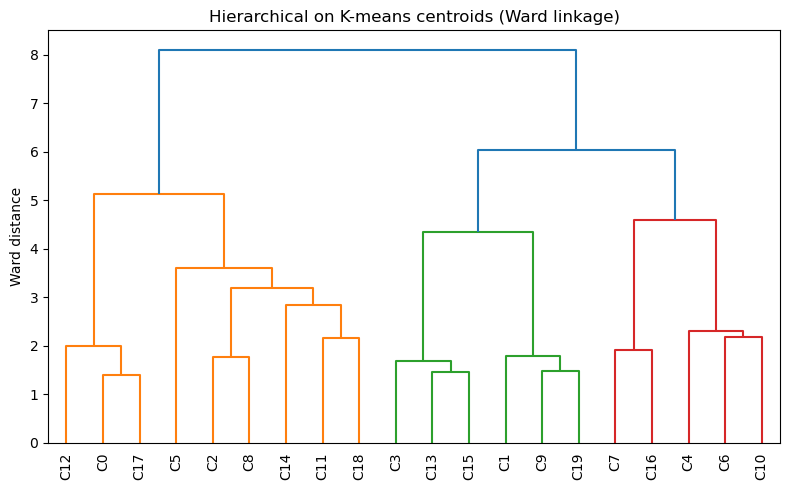

In [24]:
Z = linkage(centroids_df_hierarchical, method='ward')

plt.figure(figsize=(8, 5))
dendrogram(
    Z,
    labels=[f"C{i}" for i in range(len(centroids_df_hierarchical))],  
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=None   
)
plt.title("Hierarchical on K-means centroids (Ward linkage)")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()

In [25]:
n_macro = 6
macro_labels = fcluster(Z, t=n_macro, criterion='maxclust')   

pd.Series(macro_labels).value_counts().sort_index()


1    3
2    6
3    3
4    3
5    2
6    3
Name: count, dtype: int64

In [26]:
centroid_to_macro = {idx: lab for idx, lab in enumerate(macro_labels)}

info_clustering_hierarchical["macro_cluster"] = (
    info_clustering_hierarchical["kmeans20_cluster"]
      .map(centroid_to_macro)
)

info_clustering_hierarchical["macro_cluster"].value_counts()


macro_cluster
2    10851
4     5205
6     4645
1     4550
3     4295
5     2882
Name: count, dtype: int64

In [27]:
info_clustering_hierarchical

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,...,age,hour_sin,hour_cos,years_education,years_since_first_transaction,lifetime_spend_techonology,has_loyalty_card,customer_gender,kmeans20_cluster,macro_cluster
customer_id,,,,,,,,,,,,,,,,,,,,,
29930,1.0,1.0,0.0,0.5,-0.375254,0.323394,1.214118,0.567444,1.029630,1.222782,...,-0.027101,-0.183013,-0.366025,-0.6,-0.428571,0.632947,0,1,13,3
6813,-1.0,0.0,-1.0,0.5,-0.332876,0.399083,-0.809412,-0.622151,-0.240000,-0.337702,...,0.855364,-0.353553,-0.224745,0.0,0.285714,-0.656762,1,0,8,2
39451,1.0,1.0,-1.0,1.5,0.008118,1.308486,1.256471,1.274336,0.622222,1.300403,...,-0.600101,-0.353553,-0.224745,-0.6,0.571429,0.326415,0,1,13,3
16415,0.0,0.0,0.0,1.0,1.658394,-0.213303,0.658824,-0.146956,0.118519,0.817540,...,0.150113,-0.353553,-0.224745,1.4,0.428571,0.042167,1,0,1,4
22853,0.0,0.0,0.0,0.0,0.551196,1.857798,-0.157647,-0.131939,-1.334815,-0.638105,...,0.674102,-0.707107,1.000000,1.4,0.285714,0.103343,1,1,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37071,0.0,0.0,-1.0,-0.5,2.299522,0.423165,0.192941,0.901046,-0.320000,1.014113,...,-0.895312,-0.612372,0.292893,-0.6,-0.428571,0.549050,0,1,6,6
27422,0.0,0.0,-1.0,0.0,0.031613,0.066514,0.710588,0.010727,0.440000,-0.113911,...,-0.430278,-0.183013,-0.366025,-0.6,-0.571429,0.206030,1,0,19,4
39540,0.0,-1.0,0.0,-0.5,-0.039657,-0.048165,-0.432941,-0.214535,-0.583704,0.797379,...,-0.948547,-0.683013,0.633975,-0.6,-0.428571,1.414027,0,1,18,2


In [28]:
umap_model = umap.UMAP(
    n_neighbors=15,      
    min_dist=0.05,
    random_state=42
)
features_for_umap = info_clustering_hierarchical.drop(
                        columns=excluded_cols               
                    ).values
umap_embedding = umap_model.fit_transform(features_for_umap) 

/Users/davidcarrilho/anaconda3/envs/MachineLeaning2/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


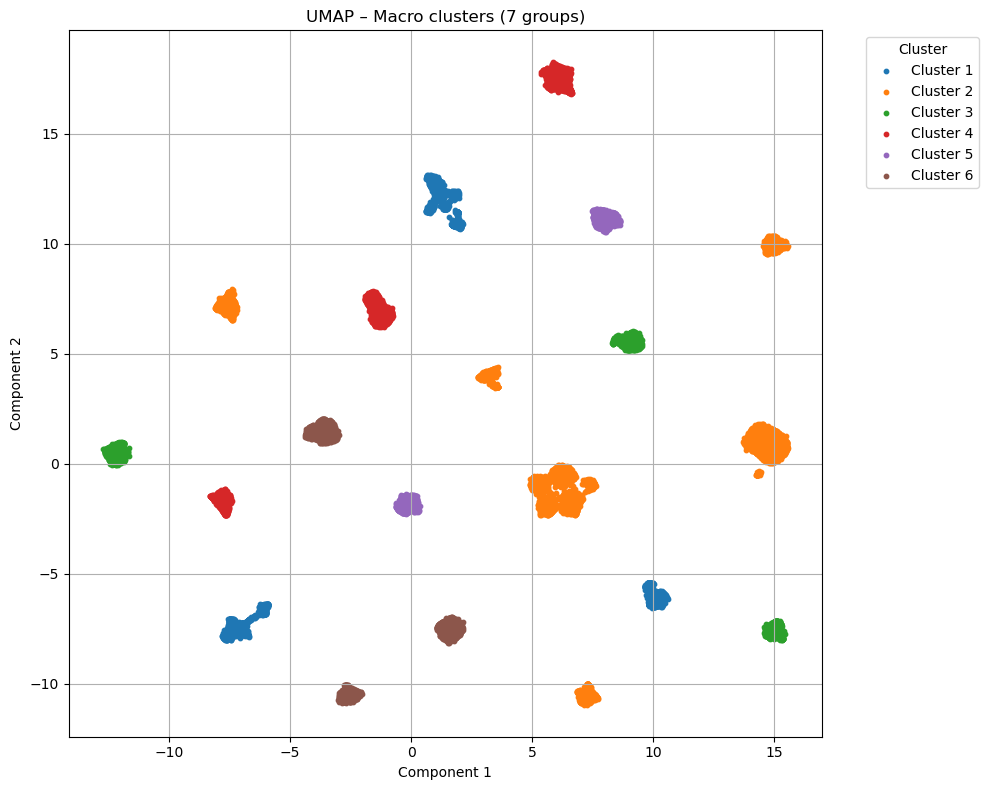

In [29]:
visualize_umap(
    embedding = umap_embedding,
    labels    = info_clustering_hierarchical["macro_cluster"].values,
    title     = "UMAP – Macro clusters (7 groups)",
    cmap_name = "tab10"          
)

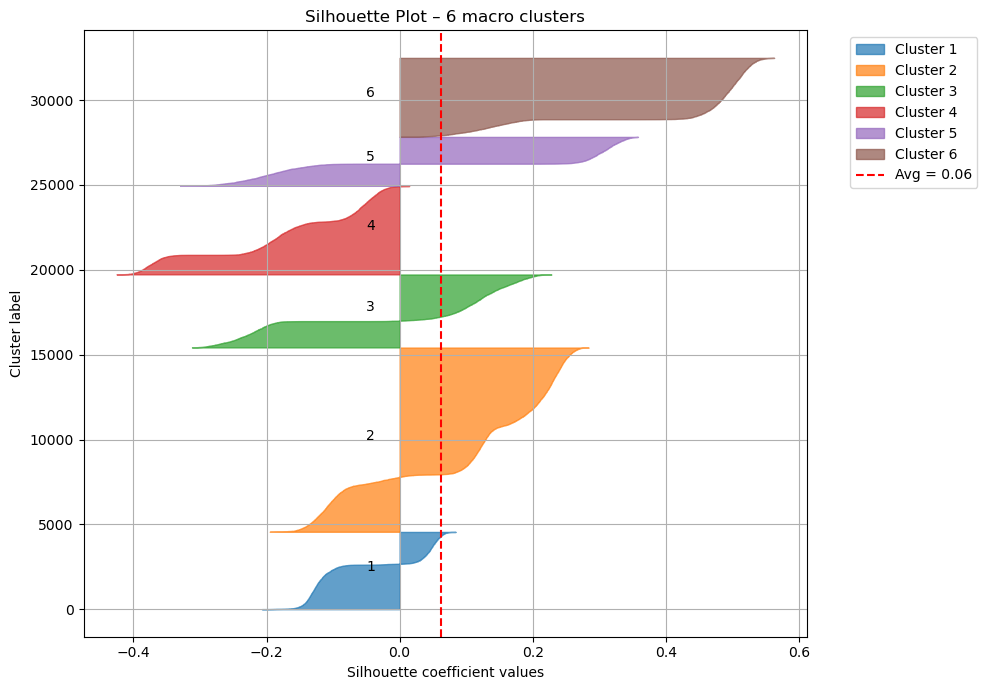

In [30]:
X_macro = (
    info_clustering_hierarchical
    .drop(columns=excluded_cols)      
    .values                           
)

labels_macro = info_clustering_hierarchical["macro_cluster"].values

silhouette_plot(
    X_macro,
    labels_macro,
    title="Silhouette Plot – 6 macro clusters"
)


As K means > K means + Hierarchical we proceed to assign the outliers to the clusters created in the K means section

In [31]:
outlier_dataset = read_outliers()

In [32]:
outlier_dataset.set_index('customer_id', inplace=True)

In [33]:
outlier_dataset_cluster = outlier_dataset.drop(columns=excluded_cols)

In [34]:
outlier_dataset_cluster

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,age,hour_sin,hour_cos,years_education,years_since_first_transaction,lifetime_spend_techonology
customer_id,,,,,,,,,,,,,,,,,,,,
21557,-0.333333,-0.5,0.0,-0.333333,-0.377468,-0.727152,-0.761688,0.737935,-0.349162,-0.400716,-0.742054,-0.2752,0.005102,0.111621,-0.125252,-0.628626,-2.247449e-01,-0.3,0.777778,1.063006
6247,-0.333333,-0.5,0.0,0.666667,2.022185,-0.491391,0.205245,-0.524131,-0.286313,-0.801431,1.473105,-0.3456,0.474490,-0.395857,0.814368,0.585786,6.339746e-01,0.2,0.888889,-0.295387
4864,0.666667,0.5,1.0,1.333333,-0.366873,0.082119,-0.367161,0.068500,0.424581,0.394753,0.297066,-0.9120,0.571429,0.191040,-0.823734,0.000000,-3.660254e-01,0.2,-1.000000,0.011156
13147,0.000000,-0.5,-1.0,0.000000,1.355122,-0.600000,-1.343216,-0.490919,-0.958101,0.093023,0.143032,-0.3040,-1.066327,2.881939,0.861356,-0.428825,-3.660254e-01,0.0,-0.111111,-0.154533
13720,-0.333333,-0.5,0.0,0.000000,-0.665778,0.527152,-0.517674,-0.087182,-0.040503,-0.312463,1.249389,-1.0336,-0.091837,2.006531,0.088249,-0.428825,-3.660254e-01,0.7,0.444444,0.978804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5653,0.666667,0.5,0.0,0.000000,0.622724,-0.103311,-0.004561,0.748313,0.572626,0.964818,0.284841,-0.4928,0.775510,0.018216,-0.759096,-0.214413,-4.142136e-01,0.7,-0.777778,-0.184217
164,-0.333333,-0.5,-1.0,-0.333333,-0.088163,-0.433113,0.729761,0.114167,-0.631285,-1.131783,-0.812958,-0.1888,-0.647959,0.318456,-0.733782,-1.042840,1.000000e+00,0.2,-0.222222,-0.131057
26471,-0.333333,0.5,1.0,-0.333333,0.141137,0.511258,-0.015964,0.579139,0.783520,-0.214669,0.167482,-0.5312,1.617347,0.361053,0.049621,0.371374,0.000000e+00,-0.3,1.444444,-0.110103


In [35]:
centroids_df_kmeans

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,age,hour_sin,hour_cos,years_education,years_since_first_transaction,lifetime_spend_techonology
kmeans_cluster,,,,,,,,,,,,,,,,,,,,
0,-0.009258,-0.691795,-0.286749,0.056670,-0.238741,1.736377,-0.117001,-0.299107,-1.250091,-0.575105,0.114243,-0.331777,-0.212748,-0.342587,0.062382,-0.130574,0.374654,0.185827,0.054190,-0.203821
1,-0.490565,-0.017948,-0.898278,-0.463691,1.817884,0.695609,0.135531,0.836035,0.725008,0.953117,0.327949,0.433694,0.223749,-0.301476,0.077689,-0.084256,0.432650,0.367160,0.175323,0.540466
2,-0.070536,-0.044009,0.096474,0.138488,-0.243995,-0.067712,-0.623907,-0.386978,-0.272341,-0.293485,-0.334088,-0.115883,-0.352333,0.913462,-0.153010,-0.005151,0.324214,-0.311688,-0.137513,-0.502449
3,1.451170,0.853892,-0.171842,0.017886,0.207292,0.406278,0.805821,0.852009,0.892565,0.598001,0.386394,0.177991,1.111434,-0.100775,0.101581,0.290258,-0.086059,0.093024,0.314486,0.495682
4,-0.722484,-0.753769,-0.234902,-0.752636,0.289627,-0.198699,0.060939,0.327594,-0.077665,0.174955,-0.414817,-0.113407,0.057636,0.172960,-0.045196,-0.187144,0.856844,0.129891,-0.383940,1.386263
5,-0.057650,0.005644,0.005538,0.414483,0.725046,-0.114148,0.575500,0.059031,0.176894,0.275534,0.868236,0.179222,0.796658,0.379881,0.085629,-0.021146,0.343856,0.097941,0.425960,0.088941


In [36]:
closest_idx, closest_dist = pairwise_distances_argmin_min(
    X = outlier_dataset_cluster.values,
    Y = centroids_df_kmeans.values,
    metric = "euclidean",        
    axis = 1                     
)

outlier_dataset_final_cluster = outlier_dataset.copy()
outlier_dataset_final_cluster["kmeans_cluster"]   = closest_idx          


In [37]:
display(outlier_dataset_final_cluster)

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,...,longitude,age,hour_sin,hour_cos,years_education,years_since_first_transaction,lifetime_spend_techonology,has_loyalty_card,customer_gender,kmeans_cluster
customer_id,,,,,,,,,,,,,,,,,,,,,
21557,-0.333333,-0.5,0.0,-0.333333,-0.377468,-0.727152,-0.761688,0.737935,-0.349162,-0.400716,...,0.001447,-0.125252,-0.628626,-2.247449e-01,-0.3,0.777778,1.063006,0.0,0.0,4
6247,-0.333333,-0.5,0.0,0.666667,2.022185,-0.491391,0.205245,-0.524131,-0.286313,-0.801431,...,0.232927,0.814368,0.585786,6.339746e-01,0.2,0.888889,-0.295387,1.0,1.0,5
4864,0.666667,0.5,1.0,1.333333,-0.366873,0.082119,-0.367161,0.068500,0.424581,0.394753,...,0.823396,-0.823734,0.000000,-3.660254e-01,0.2,-1.000000,0.011156,1.0,1.0,2
13147,0.000000,-0.5,-1.0,0.000000,1.355122,-0.600000,-1.343216,-0.490919,-0.958101,0.093023,...,0.836436,0.861356,-0.428825,-3.660254e-01,0.0,-0.111111,-0.154533,0.0,0.0,2
13720,-0.333333,-0.5,0.0,0.000000,-0.665778,0.527152,-0.517674,-0.087182,-0.040503,-0.312463,...,0.952407,0.088249,-0.428825,-3.660254e-01,0.7,0.444444,0.978804,0.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5653,0.666667,0.5,0.0,0.000000,0.622724,-0.103311,-0.004561,0.748313,0.572626,0.964818,...,-0.114588,-0.759096,-0.214413,-4.142136e-01,0.7,-0.777778,-0.184217,1.0,1.0,3
164,-0.333333,-0.5,-1.0,-0.333333,-0.088163,-0.433113,0.729761,0.114167,-0.631285,-1.131783,...,-0.112381,-0.733782,-1.042840,1.000000e+00,0.2,-0.222222,-0.131057,1.0,1.0,2
26471,-0.333333,0.5,1.0,-0.333333,0.141137,0.511258,-0.015964,0.579139,0.783520,-0.214669,...,-0.018910,0.049621,0.371374,0.000000e+00,-0.3,1.444444,-0.110103,1.0,1.0,5


In [38]:
dataset_cluster = pd.concat([info_clustering_kmeans, outlier_dataset_final_cluster], axis=0)


In [39]:
dataset_cluster

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,...,longitude,age,hour_sin,hour_cos,years_education,years_since_first_transaction,lifetime_spend_techonology,has_loyalty_card,customer_gender,kmeans_cluster
customer_id,,,,,,,,,,,,,,,,,,,,,
29930,1.000000,1.0,0.0,0.500000,-0.375254,0.323394,1.214118,0.567444,1.029630,1.222782,...,0.895939,-0.027101,-0.183013,-3.660254e-01,-0.6,-0.428571,0.632947,0.0,1.0,3
6813,-1.000000,0.0,-1.0,0.500000,-0.332876,0.399083,-0.809412,-0.622151,-0.240000,-0.337702,...,-0.187761,0.855364,-0.353553,-2.247449e-01,0.0,0.285714,-0.656762,1.0,0.0,2
39451,1.000000,1.0,-1.0,1.500000,0.008118,1.308486,1.256471,1.274336,0.622222,1.300403,...,0.281558,-0.600101,-0.353553,-2.247449e-01,-0.6,0.571429,0.326415,0.0,1.0,3
16415,0.000000,0.0,0.0,1.000000,1.658394,-0.213303,0.658824,-0.146956,0.118519,0.817540,...,0.220402,0.150113,-0.353553,-2.247449e-01,1.4,0.428571,0.042167,1.0,0.0,5
22853,0.000000,0.0,0.0,0.000000,0.551196,1.857798,-0.157647,-0.131939,-1.334815,-0.638105,...,-0.533152,0.674102,-0.707107,1.000000e+00,1.4,0.285714,0.103343,1.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5653,0.666667,0.5,0.0,0.000000,0.622724,-0.103311,-0.004561,0.748313,0.572626,0.964818,...,-0.114588,-0.759096,-0.214413,-4.142136e-01,0.7,-0.777778,-0.184217,1.0,1.0,3
164,-0.333333,-0.5,-1.0,-0.333333,-0.088163,-0.433113,0.729761,0.114167,-0.631285,-1.131783,...,-0.112381,-0.733782,-1.042840,1.000000e+00,0.2,-0.222222,-0.131057,1.0,1.0,2
26471,-0.333333,0.5,1.0,-0.333333,0.141137,0.511258,-0.015964,0.579139,0.783520,-0.214669,...,-0.018910,0.049621,0.371374,0.000000e+00,-0.3,1.444444,-0.110103,1.0,1.0,5


In [40]:
#dataset_cluster.to_csv("dataset_cluster_final.csv", index=True)